# Module 8 — Selective Prediction and Possible-OOD Audit

**Question.** Can calibrated confidence signals support a locked abstention boundary that preserves useful known-request coverage, limits accepted-request error, and rejects synthetic non-banking requests?

**Registered assessment gates.** Known coverage ≥ 70%, selective risk ≤ 5%, and synthetic possible-OOD recall ≥ 90% for every seed.

**Claim boundary.** This notebook reads text-free role registries and reports only. It does not load messages, logits, model weights or BANKING77's official test split. Known data have prior checkpoint-selection and calibration-assessment history; possible-OOD data are synthetic.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs/uncertainty.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the project repository")


ROOT = find_repository_root(Path.cwd().resolve())
REPORT_DIR = ROOT / "reports/uncertainty"
REGISTRY_PATH = ROOT / "data/manifests/banking77-uncertainty-index.json"
SEEDS = (17, 42, 73)

registry = json.loads(REGISTRY_PATH.read_text(encoding="utf-8"))
reports = {
    seed: json.loads((REPORT_DIR / f"seed-{seed}-selective-ood.json").read_text(encoding="utf-8"))
    for seed in SEEDS
}
aggregate = json.loads((REPORT_DIR / "selective-ood-aggregate.json").read_text(encoding="utf-8"))
ROOT

PosixPath('/Users/coded/Downloads/IAPP-Artificial-Intelligence-Governance-Professional-AIGP-Complete-Course/AI Engineer/governed-banking-intent-router')

## 1. Verify role separation and evidence scope

Threshold choice is meaningful only when development rows, assessment rows and scenario groups do not cross roles.

In [2]:
partition_rows = []
for entry in registry["known_entries"]:
    development = set(entry["threshold_known_development"]["source_indices"])
    assessment = set(entry["selective_known_assessment"]["source_indices"])
    assert development.isdisjoint(assessment)
    assert entry["normalized_text_group_overlap"] == 0
    partition_rows.append(
        {
            "seed": entry["seed"],
            "known_development": len(development),
            "known_assessment": len(assessment),
            "known_overlap": len(development & assessment),
        }
    )
ood = registry["possible_ood"]
ood_development_groups = set(ood["threshold_ood_development"]["scenario_groups"])
ood_assessment_groups = set(ood["possible_ood_assessment"]["scenario_groups"])
assert ood_development_groups.isdisjoint(ood_assessment_groups)
assert registry["contains_message_text"] is False
assert registry["model_access_boundary"]["test_split_loaded"] is False
assert aggregate["data_boundary"]["independent_model_evaluation"] is False

partition_frame = pd.DataFrame(partition_rows).set_index("seed")
partition_frame["ood_development"] = ood["threshold_ood_development"]["count"]
partition_frame["ood_assessment"] = ood["possible_ood_assessment"]["count"]
partition_frame

,known_development,known_assessment,known_overlap,ood_development,ood_assessment
seed,,,,,
17,375,375,0,48,48
42,375,376,0,48,48
73,375,375,0,48,48


## 2. Inspect locked operating points

Signal choice and threshold were frozen from development evidence before these assessment metrics were calculated. A failed gate remains failed.

In [3]:
assessment_rows = []
for seed, report in reports.items():
    metrics = report["assessment"]["metrics"]
    assessment_rows.append(
        {
            "seed": seed,
            "signal": report["assessment"]["selected_signal"],
            "threshold": report["assessment"]["locked_threshold"],
            "known_coverage": metrics["known_coverage"],
            "selective_risk": metrics["selective_risk"],
            "error_capture_rate": metrics["error_capture_rate"],
            "possible_ood_recall": metrics["possible_ood_recall"],
            "possible_ood_auroc": metrics["possible_ood_auroc"],
            "aurc": metrics["aurc"],
            "gate_passed": report["acceptance_gate"]["all_passed"],
        }
    )
assessment_frame = pd.DataFrame(assessment_rows).set_index("seed")
assert not assessment_frame["gate_passed"].any()
assessment_frame.round(4)

,signal,threshold,known_coverage,selective_risk,error_capture_rate,possible_ood_recall,possible_ood_auroc,aurc,gate_passed
seed,,,,,,,,,
17,inverse_normalized_entropy,0.7378,0.9200,0.0609,0.4474,0.8542,0.9546,0.0143,False
42,max_probability,0.5916,0.9362,0.0597,0.3636,0.8750,0.9586,0.0129,False
73,inverse_normalized_entropy,0.7666,0.8827,0.0725,0.4894,0.9375,0.9699,0.0232,False


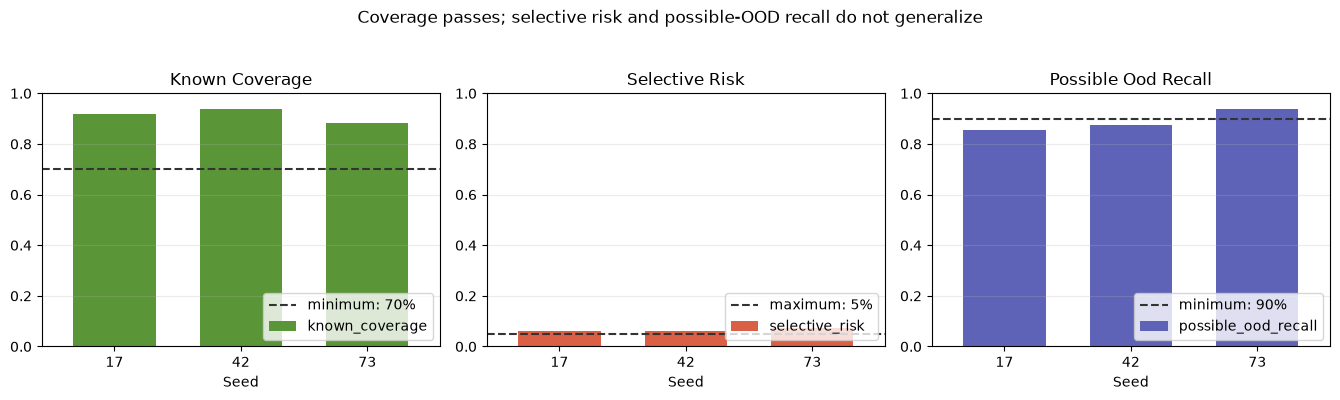

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
plots = (
    ("known_coverage", 0.70, "minimum", "#5a9637"),
    ("selective_risk", 0.05, "maximum", "#d95f45"),
    ("possible_ood_recall", 0.90, "minimum", "#5f63b8"),
)
for axis, (metric, target, direction, color) in zip(axes, plots, strict=True):
    assessment_frame[metric].plot(kind="bar", ax=axis, color=color, width=0.65)
    axis.axhline(
        target,
        linestyle="--",
        color="#333333",
        label=f"{direction}: {target:.0%}",
    )
    axis.set_title(metric.replace("_", " ").title())
    axis.set_xlabel("Seed")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=0)
    axis.grid(axis="y", alpha=0.25)
    axis.legend(loc="lower right")
fig.suptitle(
    "Coverage passes; selective risk and possible-OOD recall do not generalize",
    y=1.04,
)
fig.tight_layout()
plt.show()

## 3. Separate ranking quality from operating-point safety

AUROC summarizes every possible threshold. Deployment requires one locked threshold, so strong ranking cannot substitute for passing the operating-point gates.

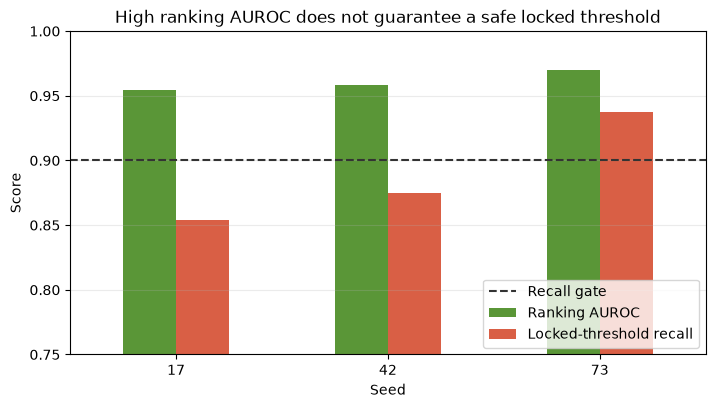

In [5]:
comparison = assessment_frame[["possible_ood_auroc", "possible_ood_recall"]].copy()
comparison.columns = ["Ranking AUROC", "Locked-threshold recall"]
axis = comparison.plot(kind="bar", figsize=(8.2, 4.2), color=["#5a9637", "#d95f45"])
axis.axhline(0.90, linestyle="--", color="#333333", label="Recall gate")
axis.set(ylabel="Score", xlabel="Seed", ylim=(0.75, 1.0))
axis.set_title("High ranking AUROC does not guarantee a safe locked threshold")
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y", alpha=0.25)
axis.legend(loc="lower right")
plt.show()

## 4. Inspect known-request risk across coverage

These curves use only selective_known_assessment. Lower risk is better; choosing a new point after viewing these curves would be post-hoc threshold tuning.

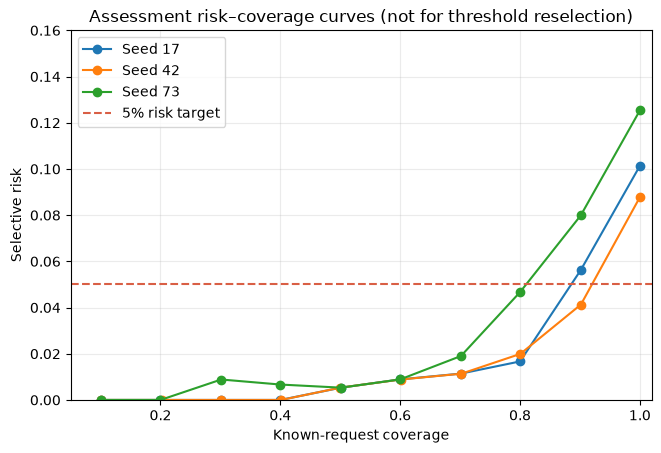

In [6]:
fig, axis = plt.subplots(figsize=(7.5, 4.8))
for seed, report in reports.items():
    curve = report["assessment"]["risk_coverage"]["curve"]
    axis.plot(
        [point["coverage"] for point in curve],
        [point["risk"] for point in curve],
        marker="o",
        label=f"Seed {seed}",
    )
axis.axhline(0.05, linestyle="--", color="#d95f45", label="5% risk target")
axis.set(
    xlabel="Known-request coverage",
    ylabel="Selective risk",
    xlim=(0.05, 1.02),
    ylim=(0, 0.16),
)
axis.set_title("Assessment risk–coverage curves (not for threshold reselection)")
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## 5. Locate synthetic possible-OOD failure domains

Each domain has only four assessment messages, so this table is a diagnostic—not a stable domain estimate.

In [7]:
domain_rows = []
for seed, report in reports.items():
    domain_metrics = report["assessment"]["possible_ood_recall_by_domain"]
    for domain, values in domain_metrics.items():
        domain_rows.append({"seed": seed, "domain": domain, "recall": values["recall"]})
domain_frame = pd.DataFrame(domain_rows).pivot(index="domain", columns="seed", values="recall")
domain_frame["mean"] = domain_frame.mean(axis=1)
domain_frame.sort_values("mean").round(2)

seed,17,42,73,mean
domain,,,,
public_services,0.25,0.50,0.50,0.42
shopping_delivery,0.50,0.75,0.75,0.67
general_knowledge,0.75,0.75,1.00,0.83
workplace,0.75,0.75,1.00,0.83
healthcare,1.00,0.75,1.00,0.92
device_support,1.00,1.00,1.00,1.00
education,1.00,1.00,1.00,1.00
entertainment,1.00,1.00,1.00,1.00
food_dining,1.00,1.00,1.00,1.00


## Conclusion

The controlled experiment found useful possible-OOD ranking (mean AUROC 0.9611) but no safe registered operating point. Mean coverage was 91.3%, mean selective risk was 6.43%, and mean synthetic possible-OOD recall was 88.9%. Every seed failed at least the selective-risk ceiling.

Public-services and shopping/delivery requests were recurring confident false accepts, while the selected signal changed across seeds. Module 9 may log these uncertainty signals and default uncertain cases to review, but it must not present the Module 8 thresholds as production approved.